# 02 — Treinamento NER com spaCy

Quatro configurações foram treinadas para permitir a comparação sistemática solicitada na atividade.

In [1]:
import json, random
from pathlib import Path
import spacy
from spacy.training import Example
from spacy.util import minibatch

def load_jsonl(path):
    with open(path,encoding="utf-8") as f: return [json.loads(x) for x in f]
train_data=load_jsonl("../data/processed/tv_train.jsonl")
LABELS=["PRODUTO","MARCA","TAMANHO","TECNOLOGIA","RESOLUCAO","RECURSO","REFERENCIA"]
print("Treino:",len(train_data))

Treino: 654


Quatro experimentos com diferentes epócas:

In [2]:
EXPERIMENTS=[
 {"id":"EXP-01","epochs":10,"dropout":0.2},
 {"id":"EXP-02","epochs":20,"dropout":0.2},
 {"id":"EXP-03","epochs":30,"dropout":0.2},
 {"id":"EXP-04","epochs":20,"dropout":0.3},
]
EXPERIMENTS

[{'id': 'EXP-01', 'epochs': 10, 'dropout': 0.2},
 {'id': 'EXP-02', 'epochs': 20, 'dropout': 0.2},
 {'id': 'EXP-03', 'epochs': 30, 'dropout': 0.2},
 {'id': 'EXP-04', 'epochs': 20, 'dropout': 0.3}]

In [3]:
def train_experiment(data,exp,seed=42):
    random.seed(seed)
    nlp=spacy.blank("pt")
    ner=nlp.add_pipe("ner")
    for label in LABELS: ner.add_label(label)
    examples=[Example.from_dict(nlp.make_doc(x["text"]),{"entities":x["entities"]}) for x in data]
    optimizer=nlp.initialize(get_examples=lambda: examples)
    losses=[]
    for epoch in range(exp["epochs"]):
        random.shuffle(examples); loss={}
        for batch in minibatch(examples,size=8):
            nlp.update(batch,drop=exp["dropout"],losses=loss)
        losses.append(loss.get("ner",0.0))
    return nlp,losses

In [4]:
models_dir=Path("../models"); models_dir.mkdir(exist_ok=True)
training_history={}
for exp in EXPERIMENTS:
    print("Treinando",exp["id"])
    model,losses=train_experiment(train_data,exp)
    model.to_disk(models_dir/exp["id"])
    training_history[exp["id"]]=losses
print("Concluído.")

Treinando EXP-01
Treinando EXP-02
Treinando EXP-03
Treinando EXP-04
Concluído.


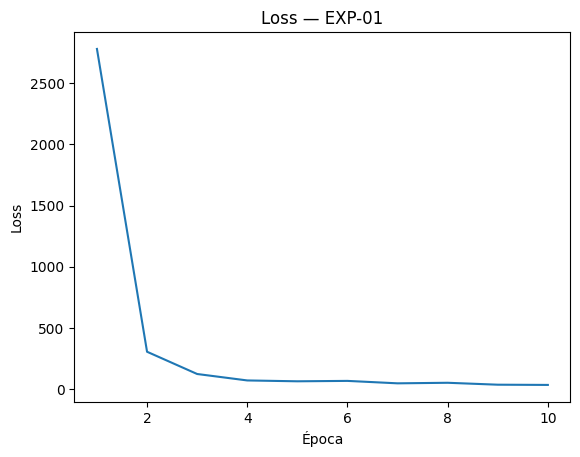

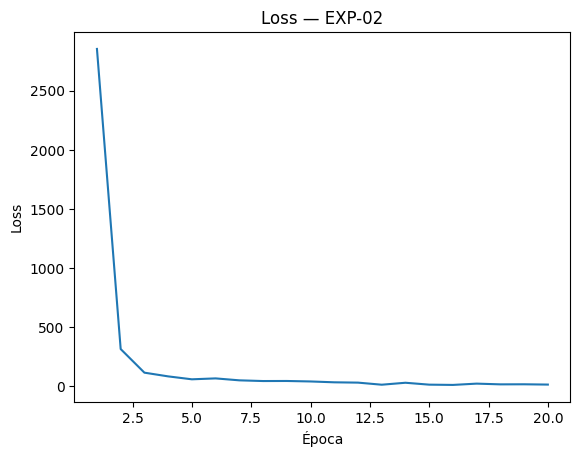

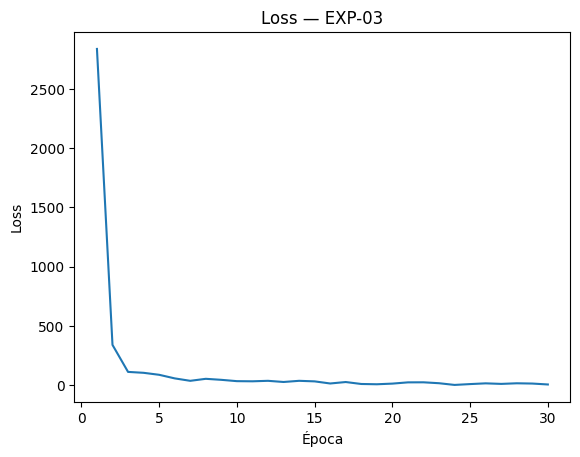

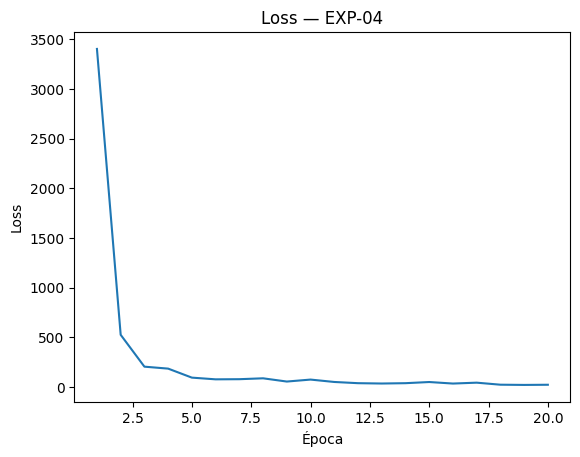

In [5]:
import matplotlib.pyplot as plt
for exp_id,losses in training_history.items():
    plt.figure()
    plt.plot(range(1,len(losses)+1),losses)
    plt.title(f"Loss — {exp_id}")
    plt.xlabel("Época"); plt.ylabel("Loss")
    plt.show()

In [6]:
import numpy as np

# Convert np.float32 values to standard Python floats
serializable_training_history = {}
for exp_id, losses in training_history.items():
    serializable_training_history[exp_id] = [float(loss) for loss in losses]

with open("../models/training_history.json","w") as f: json.dump(serializable_training_history,f)
print("Histórico salvo.")

Histórico salvo.


In [7]:
import json
from pathlib import Path
from collections import defaultdict
import spacy
import pandas as pd
import matplotlib.pyplot as plt

def load_jsonl(path):
    with open(path,encoding="utf-8") as f: return [json.loads(x) for x in f]
test_data=load_jsonl("../data/processed/tv_test.jsonl")
MODELS=Path("../models")
print("Teste:",len(test_data))

Teste: 164


In [8]:
def evaluate_model(nlp,data):
    gold_total=pred_total=tp=0
    gold=defaultdict(int); pred=defaultdict(int); hits=defaultdict(int)
    errors=[]
    for item in data:
        g={(s,e,l) for s,e,l in item["entities"]}
        d=nlp(item["text"])
        p={(e.start_char,e.end_char,e.label_) for e in d.ents}
        gold_total+=len(g); pred_total+=len(p); tp+=len(g&p)
        for _,_,l in g: gold[l]+=1
        for _,_,l in p: pred[l]+=1
        for _,_,l in g&p: hits[l]+=1
        if g!=p: errors.append((item["text"],g,p))
    precision=tp/pred_total if pred_total else 0
    recall=tp/gold_total if gold_total else 0
    f1=2*precision*recall/(precision+recall) if precision+recall else 0
    per={}
    for l in sorted(set(gold)|set(pred)):
        p=hits[l]/pred[l] if pred[l] else 0
        r=hits[l]/gold[l] if gold[l] else 0
        f=2*p*r/(p+r) if p+r else 0
        per[l]={"precision":p,"recall":r,"f1":f}
    return {"precision":precision,"recall":recall,"f1":f1,"per_label":per,"errors":errors}

In [9]:
results={}
for exp_id in ["EXP-01","EXP-02","EXP-03","EXP-04"]:
    results[exp_id]=evaluate_model(spacy.load(MODELS/exp_id),test_data)
    r=results[exp_id]
    print(f"{exp_id}: Precision={r['precision']:.4f} | Recall={r['recall']:.4f} | F1={r['f1']:.4f}")

EXP-01: Precision=0.9891 | Recall=0.9891 | F1=0.9891
EXP-02: Precision=0.9891 | Recall=0.9907 | F1=0.9899
EXP-03: Precision=0.9938 | Recall=0.9969 | F1=0.9953
EXP-04: Precision=0.9876 | Recall=0.9922 | F1=0.9899


In [10]:
comparison=pd.DataFrame([{"Experimento":k,"Precision":v["precision"],"Recall":v["recall"],"F1":v["f1"]} for k,v in results.items()])
comparison

,Experimento,Precision,Recall,F1
0,EXP-01,0.989114,0.989114,0.989114
1,EXP-02,0.989130,0.990669,0.989899
2,EXP-03,0.993798,0.996890,0.995342
3,EXP-04,0.987616,0.992224,0.989915


In [11]:
rows=[]
for exp,r in results.items():
    for label,m in r["per_label"].items():
        rows.append({"Experimento":exp,"TAG":label,**m})
pd.DataFrame(rows).sort_values(["TAG","f1"],ascending=[True,False])

,Experimento,TAG,precision,recall,f1
14,EXP-03,MARCA,1.000000,1.000000,1.000000
21,EXP-04,MARCA,1.000000,1.000000,1.000000
0,EXP-01,MARCA,0.991935,1.000000,0.995951
7,EXP-02,MARCA,1.000000,0.991870,0.995918
15,EXP-03,PRODUTO,0.500000,1.000000,0.666667
22,EXP-04,PRODUTO,0.333333,1.000000,0.500000
8,EXP-02,PRODUTO,0.285714,1.000000,0.444444
1,EXP-01,PRODUTO,0.250000,0.500000,0.333333
2,EXP-01,RECURSO,1.000000,1.000000,1.000000
9,EXP-02,RECURSO,1.000000,1.000000,1.000000


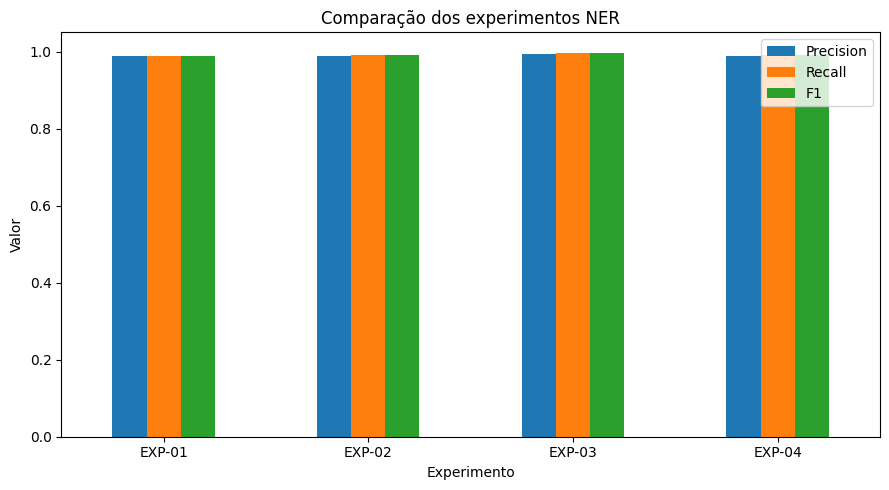

In [12]:
ax=comparison.set_index("Experimento")[["Precision","Recall","F1"]].plot(kind="bar",figsize=(9,5))
ax.set_ylim(0,1.05); ax.set_ylabel("Valor"); ax.set_title("Comparação dos experimentos NER")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## Análise qualitativa e erros

In [13]:
best_exp=comparison.loc[comparison["F1"].idxmax(),"Experimento"]
nlp=spacy.load(MODELS/best_exp)
print("Experimento para demonstração:",best_exp)
for item in test_data[:10]:
    doc=nlp(item["text"])
    print("\nTexto:",item["text"])
    print([(e.text,e.label_) for e in doc.ents])

Experimento para demonstração: EXP-03

Texto: suporte fixo para tv monitor 26 a 55 goldentec
[('tv monitor 26 a 55 goldentec', 'PRODUTO')]

Texto: suporte de mesa articulado p ate dois monitores 17 32 com ajuste de altura e pistao a gas ac372 10915
[('ac372', 'REFERENCIA')]

Texto: smart tv led 55 uhd 4k lg 55um7470psa
[('smart tv', 'RECURSO'), ('led', 'TECNOLOGIA'), ('uhd', 'RESOLUCAO'), ('4k', 'RESOLUCAO'), ('lg', 'MARCA')]

Texto: apple tv 4 geracao 32 gb mr912bz a
[('apple', 'MARCA'), ('tv 4 geracao 32 gb mr912bz a', 'PRODUTO')]

Texto: smart tv lg led 43 4k uhd wifi bluetooth 43uq7500psf
[('smart tv', 'RECURSO'), ('lg', 'MARCA'), ('led', 'TECNOLOGIA'), ('4k', 'RESOLUCAO'), ('uhd', 'RESOLUCAO'), ('wifi', 'RECURSO'), ('bluetooth', 'RECURSO')]

Texto: smart tv led 43 full hd sony kdl 43w665f com hdr wi fi motionflow xr 240 x protection pro x reality pro
[('smart tv', 'RECURSO'), ('led', 'TECNOLOGIA'), ('full hd', 'RESOLUCAO'), ('sony', 'MARCA'), ('wi fi', 'RECURSO')]

Texto: suporte 

In [14]:
errors=results[best_exp]["errors"]
print("Exemplos com diferença:",len(errors))
for text,g,p in errors[:10]:
    print("\nTexto:",text)
    print("Gold:",sorted(g))
    print("Pred:",sorted(p))

Exemplos com diferença: 5

Texto: apple tv 4 geracao 32 gb mr912bz a
Gold: [(0, 5, 'MARCA'), (25, 32, 'REFERENCIA')]
Pred: [(0, 5, 'MARCA'), (6, 34, 'PRODUTO')]

Texto: sounbdbar jbl bar 9 1 true wireless surround dolby atoms 410w c subwoofer jblbar913dblkbr
Gold: []
Pred: [(74, 89, 'REFERENCIA')]

Texto: tela 43 polegadas full hd conversor tv digital externo multilaser tl029 52848
Gold: [(5, 17, 'TAMANHO'), (18, 25, 'RESOLUCAO'), (55, 65, 'MARCA'), (66, 71, 'REFERENCIA')]
Pred: [(5, 17, 'TAMANHO'), (18, 25, 'RESOLUCAO'), (36, 54, 'PRODUTO'), (55, 65, 'MARCA'), (66, 71, 'REFERENCIA')]

Texto: combo casa smart tv qled 55 4k toshiba 55m550ls vidaa e depilador por luz pulsada d pille hc2121k 55286
Gold: [(11, 19, 'RECURSO'), (20, 24, 'TECNOLOGIA'), (28, 30, 'RESOLUCAO'), (90, 97, 'REFERENCIA')]
Pred: [(11, 19, 'RECURSO'), (20, 24, 'TECNOLOGIA'), (28, 30, 'RESOLUCAO')]

Texto: smart tv qled 55 samsung q7f 4k
Gold: [(0, 8, 'RECURSO'), (9, 13, 'TECNOLOGIA'), (17, 24, 'MARCA'), (29, 31, 'RESO

In [15]:
serializable={k:{"precision":v["precision"],"recall":v["recall"],"f1":v["f1"],"per_label":v["per_label"],"num_errors":len(v["errors"])} for k,v in results.items()}
with open("../models/evaluation_results.json","w",encoding="utf-8") as f:
    json.dump(serializable,f,ensure_ascii=False,indent=2)
print("Resultados salvos.")

Resultados salvos.


## Conclusão

A avaliação permite comparar sistematicamente as configurações spaCy. A configuração com maior F1 no conjunto de teste é usada para demonstração. Os resultados são iniciais porque as anotações foram produzidas por regras e devem ser revisadas manualmente.